# HLS ingest

Select STAC records from the MAAP HLS archive, virtualize every band and
resolution level of the COGs they describe, and commit a batch of granules,
metadata rows and virtual arrays together in one Icechunk commit.

Needs a `~/.netrc` entry for `urs.earthdata.nasa.gov` and AWS credentials that
can read `s3://nasa-maap-data-store`.

**Set `ACCESS` below.** `"s3"` is the fast path but LP DAAC's protected bucket
is readable that way only from AWS `us-west-2`; `"https"` works from anywhere.
The choice affects only how COG headers are fetched here -- references are
written relative to a named container (`vcc://lpdaac/...`), so this store is
readable either way whichever mode built it.


In [1]:
# 1. Open the archive and look at what a record holds.
import logging

from icechest.demo.source import open_archive, select_granules

# "s3" is faster but readable only from AWS us-west-2; "https" works anywhere.
# It decides how bytes are fetched here, not what the store records.
ACCESS = "https"

# The archive's parquet dictionary-encodes some columns; Iceberg has no
# dictionary type, so PyIceberg reads them as strings and says so, loudly.
logging.getLogger("pyiceberg.io.pyarrow").setLevel(logging.ERROR)

archive = open_archive()
rows = select_granules(archive, limit=5)
rows.select(["id", "datetime", "proj:epsg", "proj:shape", "proj:transform"]).to_pandas()


,id,datetime,proj:epsg,proj:shape,proj:transform
0,HLS.L30.T20JKP.2026004T142004.v2.0,2026-01-04 14:20:04.576000+00:00,32620,"[3660, 3660]","[30.0, 0.0, 199980.0, 0.0, -30.0, -3099960.0, ..."
1,HLS.L30.T44QLM.2026018T051400.v2.0,2026-01-18 05:14:00.270000+00:00,32644,"[3660, 3660]","[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0..."
2,HLS.L30.T44QLM.2026011T050747.v2.0,2026-01-11 05:07:47.856000+00:00,32644,"[3660, 3660]","[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0..."
3,HLS.L30.T32TML.2026017T101215.v2.0,2026-01-17 10:12:15.482000+00:00,32632,"[3660, 3660]","[30.0, 0.0, 399960.0, 0.0, -30.0, 4600020.0, 0..."
4,HLS.L30.T13SFA.2026027T172600.v2.0,2026-01-27 17:26:00.012000+00:00,32613,"[3660, 3660]","[30.0, 0.0, 600000.0, 0.0, -30.0, 4100040.0, 0..."


In [3]:
# 2. Two URLs per asset: one to read through now, one to record.
from icechest.demo.assets import asset_urls, to_vcc_url

row = rows.to_pylist()[0]
read_url = asset_urls(row, access=ACCESS)["B04"]

# The reference carries no endpoint, so a reader resolves it against
# whichever container their own store declares.
print("read through:", read_url)
print("recorded as: ", to_vcc_url(row["assets"]["B04"]["href"]))

read through: https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T20JKP.2026004T142004.v2.0/HLS.L30.T20JKP.2026004T142004.v2.0.B04.tif
recorded as:  vcc://lpdaac/HLSL30.020/HLS.L30.T20JKP.2026004T142004.v2.0/HLS.L30.T20JKP.2026004T142004.v2.0.B04.tif


In [4]:
# 3. How many resolution levels this COG carries.
from icechest.demo.credentials import object_store_registry
from icechest.demo.tiff import parse_ifds
from icechest.demo.virtualize import read_header

registry = object_store_registry(ACCESS)
parse_ifds(read_header(asset_urls(row, access=ACCESS)["B04"], registry))

[(3660, 3660), (1830, 1830), (915, 915), (458, 458), (229, 229)]

In [5]:
# 4. The convention attributes, from the record alone.
from icechest.demo.conventions import granule_attrs

granule_attrs(
    epsg=row["proj:epsg"],
    shape=row["proj:shape"],
    transform=row["proj:transform"],
    levels=5,
    array_name="B04"
)

{'zarr_conventions': [{'schema_url': 'https://raw.githubusercontent.com/zarr-conventions/multiscales/refs/tags/v0.1/schema.json',
   'spec_url': 'https://github.com/zarr-conventions/multiscales/blob/v0.1/README.md',
   'uuid': 'd35379db-88df-4056-af3a-620245f8e347',
   'name': 'multiscales',
   'description': 'Multiscale layout of zarr datasets'},
  {'schema_url': 'https://raw.githubusercontent.com/zarr-conventions/proj/refs/tags/v0.1/schema.json',
   'spec_url': 'https://github.com/zarr-conventions/proj/blob/v0.1/README.md',
   'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f',
   'name': 'proj',
   'description': 'Coordinate reference system information for geospatial data'},
  {'schema_url': 'https://raw.githubusercontent.com/zarr-conventions/spatial/refs/tags/v0.1/schema.json',
   'spec_url': 'https://github.com/zarr-conventions/spatial/blob/v0.1/README.md',
   'uuid': '689b58e2-cf7b-45e0-9fff-9cfc0883d6b4',
   'name': 'spatial',
   'description': 'Spatial coordinate information'}],
 

In [6]:
# 5. Open a local store and declare the table from the archive's own schema.
from pathlib import Path
from icechest.demo.store import ensure_table, open_store

repo = open_store(Path("hls-demo-store"), access=ACCESS)
ensure_table(repo, archive.schema())
repo.read("main").pointers

  2026-09-17T20:19:49.119357Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-17T20:19:49.135583Z  WARN icechunk::repository: DEPRECATED: passing `None` to authorize virtual chunk access for container `https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/` is deprecated and will be rejected in a future release. Pass the explicit `Credentials::HttpAccess` sentinel instead., url_prefix: "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/"
    at icechunk/src/repository.rs:2224



{'granules': 'hls-demo-store/warehouse/granules/metadata/00001-0f0f9e6e-05ee-4773-8266-4397fc6c436f.metadata.json'}

In [6]:
# 6. Ingest the batch. One commit carries the rows and every virtual array.
from icechest.demo.ingest import ingest_batch

result = ingest_batch(repo, rows, registry=registry, access=ACCESS)
result.snapshot_id, len(result.committed), result.skipped

('8XTEAVA0X3K95MVA016G', 5, {})

In [7]:
snap = repo.read("main")
granules = snap.table("granules").scan().to_arrow().to_pandas()
granules

,type,stac_version,stac_extensions,id,sci:doi,view:azimuth,links,assets,collection,datetime,...,proj:epsg,view:sun_azimuth,bbox,geometry,proj:transform,proj:shape,processing:software,array_path,stac_hash,stac_hash_block
0,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T20JKP.2026004T142004.v2.0,10.5067/HLS/HLSL30.002,282.982100,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-04 14:20:04.576000+00:00,...,32620,85.957832,"{'xmin': -66.078927, 'ymin': -28.992287, 'xmax...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 199980.0, 0.0, -30.0, -3099960.0, ...","[3660, 3660]",None,/HLS.L30.T20JKP.2026004T142004.v2.0,5059875333006593974,2247
1,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T13SFA.2026027T172600.v2.0,10.5067/HLS/HLSL30.002,105.024306,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-27 17:26:00.012000+00:00,...,32613,152.673723,"{'xmin': -103.524143, 'ymin': 36.034105, 'xmax...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 600000.0, 0.0, -30.0, 4100040.0, 0...","[3660, 3660]",None,/HLS.L30.T13SFA.2026027T172600.v2.0,6987387000757644074,3103
2,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T32TML.2026017T101215.v2.0,10.5067/HLS/HLSL30.002,281.615949,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-17 10:12:15.482000+00:00,...,32632,157.947268,"{'xmin': 7.800551, 'ymin': 40.556707, 'xmax': ...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 399960.0, 0.0, -30.0, 4600020.0, 0...","[3660, 3660]",None,/HLS.L30.T32TML.2026017T101215.v2.0,8120599908836163768,3606
3,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T44QLM.2026018T051400.v2.0,10.5067/HLS/HLSL30.002,279.664635,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-18 05:14:00.270000+00:00,...,32644,149.372071,"{'xmin': 79.02775, 'ymin': 23.488221, 'xmax': ...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0...","[3660, 3660]",None,/HLS.L30.T44QLM.2026018T051400.v2.0,8136045210481876099,3613
4,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T44QLM.2026011T050747.v2.0,10.5067/HLS/HLSL30.002,152.449304,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-11 05:07:47.856000+00:00,...,32644,149.649753,"{'xmin': 79.02775, 'ymin': 23.409409, 'xmax': ...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0...","[3660, 3660]",None,/HLS.L30.T44QLM.2026011T050747.v2.0,8136045265794864364,3613


In [8]:
CLOUD_MAX = 20
clear = granules[granules["eo:cloud_cover"] < CLOUD_MAX]
if clear.empty:  # nothing that clear in this batch; take the clearest there is
    clear = granules
clear = clear.sort_values("eo:cloud_cover")
clear


,type,stac_version,stac_extensions,id,sci:doi,view:azimuth,links,assets,collection,datetime,...,proj:epsg,view:sun_azimuth,bbox,geometry,proj:transform,proj:shape,processing:software,array_path,stac_hash,stac_hash_block
3,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T44QLM.2026018T051400.v2.0,10.5067/HLS/HLSL30.002,279.664635,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-18 05:14:00.270000+00:00,...,32644,149.372071,"{'xmin': 79.02775, 'ymin': 23.488221, 'xmax': ...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0...","[3660, 3660]",None,/HLS.L30.T44QLM.2026018T051400.v2.0,8136045210481876099,3613
4,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,HLS.L30.T44QLM.2026011T050747.v2.0,10.5067/HLS/HLSL30.002,152.449304,[{'href': 'https://data.lpdaac.earthdatacloud....,{'B01': {'href': 'https://data.lpdaac.earthdat...,HLSL30_2.0,2026-01-11 05:07:47.856000+00:00,...,32644,149.649753,"{'xmin': 79.02775, 'ymin': 23.409409, 'xmax': ...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"[30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0, 0...","[3660, 3660]",None,/HLS.L30.T44QLM.2026011T050747.v2.0,8136045265794864364,3613


In [10]:
import xarray as xr
import virtual_tiff

ds = xr.open_datatree(
    snap.store,
    engine="zarr",
    group=clear.head(1).array_path.item(),
    consolidated=False,
)
ds

<xarray.DataTree>
Group: /
├── Group: /B01
│   │   Attributes:
│   │       zarr_conventions:    [{'schema_url': 'https://raw.githubusercontent.com/z...
│   │       proj:code:           EPSG:32644
│   │       spatial:shape:       [3660, 3660]
│   │       spatial:dimensions:  ['y', 'x']
│   │       spatial:transform:   [30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0]
│   │       spatial:bbox:        [300000.0, 2590200.0, 409800.0, 2700000.0]
│   │       multiscales:         {'layout': [{'asset': 'multiscales/0/B01'}, {'asset'...
│   └── Group: /B01/multiscales
│       ├── Group: /B01/multiscales/0
│       │       Dimensions:  (y: 3660, x: 3660)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B01      (y, x) float64 107MB ...
│       ├── Group: /B01/multiscales/1
│       │       Dimensions:  (y: 1830, x: 1830)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B01      (y, x) float32 13MB ...
│       ├── Group: /B01/multiscales/2
│       │       Dimensions:  (y: 915, x: 915)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B01      (y, x) float32 3MB ...
│       ├── Group: /B01/multiscales/4
│       │       Dimensions:  (y: 229, x: 229)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B01      (y, x) float32 210kB ...
│       └── Group: /B01/multiscales/3
│               Dimensions:  (y: 458, x: 458)
│               Dimensions without coordinates: y, x
│               Data variables:
│                   B01      (y, x) float32 839kB ...
├── Group: /B03
│   │   Attributes:
│   │       zarr_conventions:    [{'schema_url': 'https://raw.githubusercontent.com/z...
│   │       proj:code:           EPSG:32644
│   │       spatial:shape:       [3660, 3660]
│   │       spatial:dimensions:  ['y', 'x']
│   │       spatial:transform:   [30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0]
│   │       spatial:bbox:        [300000.0, 2590200.0, 409800.0, 2700000.0]
│   │       multiscales:         {'layout': [{'asset': 'multiscales/0/B03'}, {'asset'...
│   └── Group: /B03/multiscales
│       ├── Group: /B03/multiscales/0
│       │       Dimensions:  (y: 3660, x: 3660)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B03      (y, x) float64 107MB ...
│       ├── Group: /B03/multiscales/1
│       │       Dimensions:  (y: 1830, x: 1830)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B03      (y, x) float32 13MB ...
│       ├── Group: /B03/multiscales/4
│       │       Dimensions:  (y: 229, x: 229)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B03      (y, x) float32 210kB ...
│       ├── Group: /B03/multiscales/3
│       │       Dimensions:  (y: 458, x: 458)
│       │       Dimensions without coordinates: y, x
│       │       Data variables:
│       │           B03      (y, x) float32 839kB ...
│       └── Group: /B03/multiscales/2
│               Dimensions:  (y: 915, x: 915)
│               Dimensions without coordinates: y, x
│               Data variables:
│                   B03      (y, x) float32 3MB ...
├── Group: /B04
│   │   Attributes:
│   │       zarr_conventions:    [{'schema_url': 'https://raw.githubusercontent.com/z...
│   │       proj:code:           EPSG:32644
│   │       spatial:shape:       [3660, 3660]
│   │       spatial:dimensions:  ['y', 'x']
│   │       spatial:transform:   [30.0, 0.0, 300000.0, 0.0, -30.0, 2700000.0]
│   │       spatial:bbox:        [300000.0, 2590200.0, 409800.0, 2700000.0]
│   │       multiscales:         {'layout': [{'asset': 'multiscales/0/B04'}, {'asset'...
│   └── Group: /B04/multiscales
│       ├── Group: /B04/multiscales/3
│       │       Dimensions:  (y: 458, x: 458)
│       │       Dimensions without coordinates: y, x
│ 

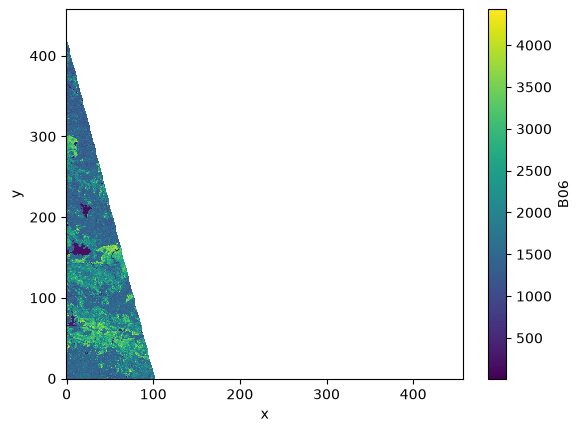

In [12]:
ds.B06.multiscales["3"].B06.plot()